# 1 — Install

In [1]:
import subprocess, sys, os

FLAG = '/tmp/fre_installed.flag'
if not os.path.exists(FLAG):
    pkgs = [
        'numpy==1.24.4',
        'facenet-pytorch==2.5.3',
        'onnx>=1.14.0',
        'onnxruntime>=1.15.0',
        'seaborn>=0.12.0',
        'pyyaml>=6.0',
        'tensorboard>=2.13.0',
    ]
    for p in pkgs:
        print(f'Installing {p}...', end=' ', flush=True)
        r = subprocess.run([sys.executable,'-m','pip','install','-q',p],
                           capture_output=True, text=True)
        print('OK' if r.returncode==0 else f'GAGAL: {r.stderr[-100:]}')
    open(FLAG, 'w').close()
    print('\n== INSTALL SELESAI ==')
    print('Klik: Runtime -> Restart Runtime')
    print('Lalu jalankan mulai dari cell berikutnya')
else:
    print('Packages sudah terinstall.')

Installing numpy==1.24.4... GAGAL: e for output.

note: This error originates from a subprocess, and is likely not a problem with pip.

Installing facenet-pytorch==2.5.3... OK
Installing onnx>=1.14.0... OK
Installing onnxruntime>=1.15.0... OK
Installing seaborn>=0.12.0... OK
Installing pyyaml>=6.0... OK
Installing tensorboard>=2.13.0... OK

== INSTALL SELESAI ==
Klik: Runtime -> Restart Runtime
Lalu jalankan mulai dari cell berikutnya


# 2 — Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_DIR = '/content/drive/MyDrive/Projek/face_recognition_ewallet'

In [4]:
import sys, os
sys.path.insert(0, BASE_DIR)
os.chdir(BASE_DIR)

from src.utils import load_config, resolve_paths, set_seed, setup_logging, get_device

cfg    = load_config('config/config.yaml')
cfg    = resolve_paths(cfg, BASE_DIR)
set_seed(cfg['project']['seed'])
device = get_device()
setup_logging(cfg['paths']['logs'], 'inference')
print(f"Setup selesai | device={device}")

⚠️  GPU tidak ditemukan — pakai CPU (training akan lambat)
Setup selesai | device=cpu


# 3 — Load Model

In [5]:
import pickle, torch
from src.models.backbone import FaceRecognitionModel

with open(f"{cfg['paths']['results']}/split.pkl", 'rb') as f:
    meta = pickle.load(f)
num_classes  = meta['num_classes']
idx_to_class = meta['idx_to_class']
test_d       = meta['test']

ckpt  = torch.load(f"{cfg['paths']['checkpoints']}/best_model.pt", map_location=device)
model = FaceRecognitionModel(num_classes, cfg).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Model di-load | val_acc={ckpt['val_acc']:.4f} ({ckpt['val_acc']*100:.2f}%)")

  0%|          | 0.00/107M [00:00<?, ?B/s]

[02:14:12][INFO] FaceRecognitionModel | backbone=InceptionResnetV1 pretrained=vggface2 | head→105 kelas


Model di-load | val_acc=0.9966 (99.66%)


# 4 — Export

In [6]:
from src.export.exporter import Exporter

exporter     = Exporter(model, cfg, device)
export_paths = exporter.export_all()

print("\nFile yang dihasilkan:")
for fmt, path in export_paths.items():
    import os
    size_mb = os.path.getsize(path) / 1e6
    print(f"  {fmt:15s} -> {path}  ({size_mb:.1f} MB)")

[02:14:14][INFO] Memulai export semua format ...
[02:14:22][INFO] TorchScript → /content/drive/MyDrive/Projek/face_recognition_ewallet/exports/torchscript/face_recognition.pt  (113.2 MB)
[02:14:22][ERROR] ONNX gagal: No module named 'onnxscript'
[02:14:22][INFO] Export selesai.



File yang dihasilkan:
  torchscript     -> /content/drive/MyDrive/Projek/face_recognition_ewallet/exports/torchscript/face_recognition.pt  (113.2 MB)


# 5 — Bangun Embedding Database

In [7]:
from src.data.dataset_loader import FaceDataset
from src.data.augmentation import get_val_transform
from src.data.preprocessor import FacePreprocessor
from src.inference.predictor import EmbeddingDB, FacePredictor
from torch.utils.data import DataLoader

val_tf      = get_val_transform(cfg)
test_ds     = FaceDataset(test_d[0], test_d[1], transform=val_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False,
                         num_workers=cfg['data']['num_workers'])

prep = FacePreprocessor(cfg, device)

db_path   = f"{cfg['paths']['exports']}/embedding_db.pkl"
db        = EmbeddingDB(path=db_path)
predictor = FacePredictor(model, prep, db, cfg, device)

predictor.build_db_from_loader(test_loader, idx_to_class)
db.save()
print(f"Database: {len(db)} identitas -> {db_path}")

[02:14:25][INFO] NumExpr defaulting to 2 threads.
[02:19:42][INFO] Enrolled: 'Jennifer Lawrence' | DB size: 1
[02:19:42][INFO] Enrolled: 'Dominic Purcell' | DB size: 2
[02:19:42][INFO] Enrolled: 'Jessica Barden' | DB size: 3
[02:19:42][INFO] Enrolled: 'Zoe Saldana' | DB size: 4
[02:19:42][INFO] Enrolled: 'grant gustin' | DB size: 5
[02:19:42][INFO] Enrolled: 'Selena Gomez' | DB size: 6
[02:19:42][INFO] Enrolled: 'Adriana Lima' | DB size: 7
[02:19:42][INFO] Enrolled: 'kiernen shipka' | DB size: 8
[02:19:42][INFO] Enrolled: 'Zendaya' | DB size: 9
[02:19:42][INFO] Enrolled: 'Robert De Niro' | DB size: 10
[02:19:42][INFO] Enrolled: 'Katherine Langford' | DB size: 11
[02:19:42][INFO] Enrolled: 'Alex Lawther' | DB size: 12
[02:19:42][INFO] Enrolled: 'alycia dabnem carey' | DB size: 13
[02:19:42][INFO] Enrolled: 'margot robbie' | DB size: 14
[02:19:42][INFO] Enrolled: 'Henry Cavil' | DB size: 15
[02:19:42][INFO] Enrolled: 'Chris Evans' | DB size: 16
[02:19:42][INFO] Enrolled: 'Ben Affleck' | 

Database: 105 identitas -> /content/drive/MyDrive/Projek/face_recognition_ewallet/exports/embedding_db.pkl


# 6 — Demo Auto-Standardize Input

Input asli    : 160x160 px  (rasio 1.00:1)
Setelah proses: (3, 160, 160)  range [-1.00, 1.00]
Identitas asli: Penn Badgley


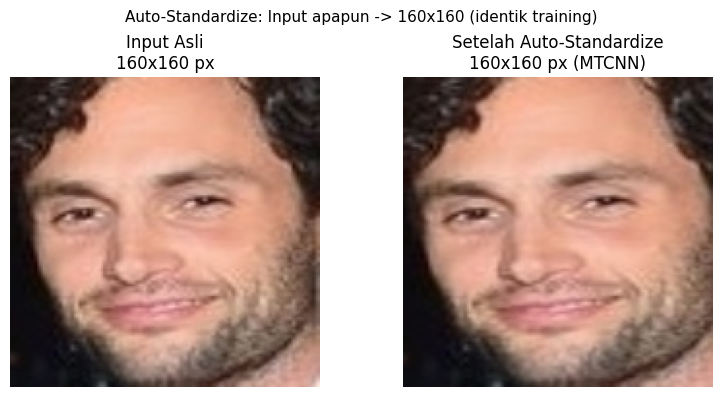

In [8]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from PIL import Image
import random
from src.data.augmentation import denormalize

idx       = random.randint(0, len(test_d[0]) - 1)
img_path  = test_d[0][idx]
label_idx = test_d[1][idx]
true_name = idx_to_class.get(str(label_idx), idx_to_class.get(label_idx, '?'))

img = Image.open(img_path).convert('RGB')
print(f"Input asli    : {img.size[0]}x{img.size[1]} px  (rasio {img.size[0]/img.size[1]:.2f}:1)")

face_tensor = prep.process_image(img)
print(f"Setelah proses: {tuple(face_tensor.shape)}  range [{face_tensor.min():.2f}, {face_tensor.max():.2f}]")
print(f"Identitas asli: {true_name}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img)
axes[0].set_title(f"Input Asli\n{img.size[0]}x{img.size[1]} px")
axes[0].axis('off')
axes[1].imshow(denormalize(face_tensor))
axes[1].set_title("Setelah Auto-Standardize\n160x160 px (MTCNN)")
axes[1].axis('off')
plt.suptitle('Auto-Standardize: Input apapun -> 160x160 (identik training)', fontsize=11)
plt.tight_layout(); plt.show()

# 7 — Verifikasi 1:1

In [9]:
result_true = predictor.verify(img, true_name)
print("=== Verifikasi: Identitas BENAR ===")
print(f"  Diklaim    : {result_true['claimed_identity']}")
print(f"  Similarity : {result_true['similarity']:.4f}  (threshold={result_true['threshold']})")
print(f"  Confidence : {result_true['confidence']}")
print(f"  Hasil      : {'MATCH' if result_true['match'] else 'NO MATCH'}")

all_names  = list(db.db.keys())
wrong_name = random.choice([n for n in all_names if n != true_name])
result_fake = predictor.verify(img, wrong_name)
print("\n=== Verifikasi: Identitas SALAH (impostor) ===")
print(f"  Diklaim    : {result_fake['claimed_identity']}")
print(f"  Similarity : {result_fake['similarity']:.4f}")
print(f"  Hasil      : {'FALSE ACCEPT (bahaya!)' if result_fake['match'] else 'CORRECTLY REJECTED'}")

=== Verifikasi: Identitas BENAR ===
  Diklaim    : Penn Badgley
  Similarity : 0.9182  (threshold=0.6)
  Confidence : HIGH
  Hasil      : MATCH

=== Verifikasi: Identitas SALAH (impostor) ===
  Diklaim    : Henry Cavil
  Similarity : 0.0716
  Hasil      : CORRECTLY REJECTED


# 8 — Identifikasi 1:N

In [10]:
result_id = predictor.identify(img)
top_k     = cfg['inference']['top_k']

print(f"=== Identifikasi 1:N ===")
print(f"Identitas asli  : {true_name}")
print(f"Top-{top_k} prediksi:")
for rank, (name, sim) in enumerate(result_id['top_k'], 1):
    marker = '-> BENAR' if name == true_name else ''
    print(f"  #{rank}  {name:30s}  sim={sim:.4f}  {marker}")
print(f"\nBest match : {result_id['best_match']}")
print(f"Diterima   : {result_id['accepted']}")

=== Identifikasi 1:N ===
Identitas asli  : Penn Badgley
Top-5 prediksi:
  #1  Penn Badgley                    sim=0.9182  -> BENAR
  #2  Richard Harmon                  sim=0.2806  
  #3  Jason Momoa                     sim=0.2785  
  #4  Mark Ruffalo                    sim=0.2456  
  #5  Krysten Ritter                  sim=0.2158  

Best match : Penn Badgley
Diterima   : True


# 9 — Enrollment User Baru

In [11]:
new_id   = 'demo_user_baru_123'
new_imgs = [Image.open(test_d[0][i]).convert('RGB') for i in range(3)]

print(f"Mendaftarkan '{new_id}' dari {len(new_imgs)} foto ...")
predictor.enroll(new_id, new_imgs, save=True)
print(f"DB setelah enrollment: {len(db)} identitas")

res_new = predictor.verify(new_imgs[0], new_id)
print(f"\nVerifikasi user baru:")
print(f"  Similarity : {res_new['similarity']:.4f}")
print(f"  Hasil      : {'MATCH' if res_new['match'] else 'GAGAL'}")

Mendaftarkan 'demo_user_baru_123' dari 3 foto ...


[02:19:44][INFO] Enrolled: 'demo_user_baru_123' | DB size: 106
[02:19:44][INFO] DB disimpan → /content/drive/MyDrive/Projek/face_recognition_ewallet/exports/embedding_db.pkl (106 identitas)
[02:19:44][INFO] Enrollment selesai: 'demo_user_baru_123' (3 foto)


DB setelah enrollment: 106 identitas

Verifikasi user baru:
  Similarity : 0.6615
  Hasil      : MATCH


# 10 — ONNX Inference di CPU

In [12]:
import onnxruntime as ort
import numpy as np

onnx_path = export_paths.get('onnx')
if onnx_path:
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])

    face_np = face_tensor.unsqueeze(0).numpy()
    import time
    t0      = time.time()
    output  = sess.run(['logits'], {'face_image': face_np})[0]
    elapsed = (time.time() - t0) * 1000

    pred_idx  = output.argmax(axis=1)[0]
    pred_name = idx_to_class.get(str(pred_idx), idx_to_class.get(pred_idx, '?'))

    print(f"ONNX Runtime inference (CPU):")
    print(f"  Waktu      : {elapsed:.0f} ms")
    print(f"  Prediksi   : {pred_name}")
    print(f"  Identitas  : {true_name}")
    print(f"  Benar      : {pred_name == true_name}")

# 11 — Ringkasan Final

In [13]:
from pathlib import Path

print('='*58)
print('  PROYEK SELESAI')
print('='*58)
print(f"  Model     : InceptionResnetV1 (VGGFace2 pretrained)")
print(f"  Val acc   : {ckpt['val_acc']:.4f} ({ckpt['val_acc']*100:.2f}%)")
print(f"  Kelas     : {num_classes}")
print()
print("  File output:")
print(f"    Checkpoint    : {cfg['paths']['checkpoints']}/best_model.pt")
for fmt, path in export_paths.items():
    size_mb = Path(path).stat().st_size / 1e6
    print(f"    {fmt:13s} : {path}  ({size_mb:.1f} MB)")
print(f"    Embedding DB  : {db_path}")
print()
print("  Untuk inference lokal (Windows, offline):")
print("    pip install onnxruntime facenet-pytorch pillow numpy")
print("    Pakai: exports/onnx/face_recognition.onnx")
print('='*58)

  PROYEK SELESAI
  Model     : InceptionResnetV1 (VGGFace2 pretrained)
  Val acc   : 0.9966 (99.66%)
  Kelas     : 105

  File output:
    Checkpoint    : /content/drive/MyDrive/Projek/face_recognition_ewallet/checkpoints/best_model.pt
    torchscript   : /content/drive/MyDrive/Projek/face_recognition_ewallet/exports/torchscript/face_recognition.pt  (113.2 MB)
    Embedding DB  : /content/drive/MyDrive/Projek/face_recognition_ewallet/exports/embedding_db.pkl

  Untuk inference lokal (Windows, offline):
    pip install onnxruntime facenet-pytorch pillow numpy
    Pakai: exports/onnx/face_recognition.onnx
